## ***Set up the necessary libraries and dependencies!***

In [ ]:
# TODO: Modify thus entire cell to account 
# for the BERT and pytorch libraries
import matplotlib.pylab as plb
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub

## ***Load and preprocess the images with tf.image***

In [ ]:
# TODO: Modify this entire cell to account for 
# pytorch and our BERT model.
def read_image(image_file_name):
    image = tf.io.read_file(image_file_name)
    image = tf.io.decode_jpeg(image,channels=3)
    image = tf.image.convert_image_dtype(image,tf.float32)
    image = tf.image.resize_with_pad(image,target_height=224,target_width=224)
    return image

image_url = {
    "Fireboat": "http://storage.googleapis.com/download.tensorflow.org/example_images/San_Francisco_fireboat_showing_off.jpg",
    "Giant Panda": "http://storage.googleapis.com/download.tensorflow.org/example_images/Giant_Panda_2.jpeg",
}

image_paths = {
    name: tf.keras.utils.get_file(name, url) for (name, url) in image_url.items()
}
image_name_tensors = {
    name: read_image(image_path) for (name, image_path) in image_paths.items()
}

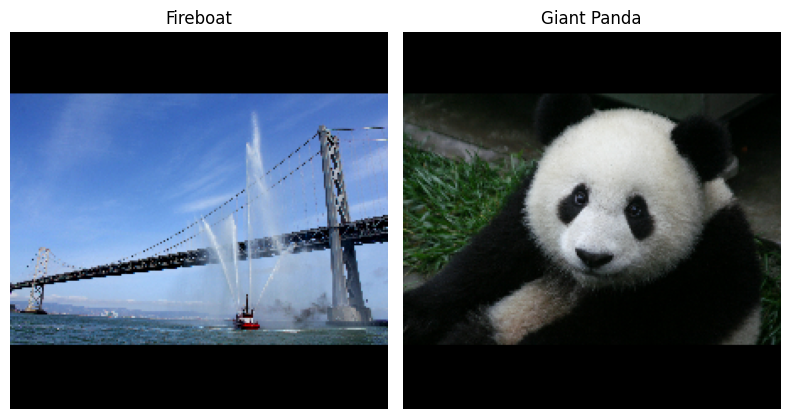

In [ ]:
# TODO: Modify this entire cell to account for pyplot.
plb.figure(figsize=(8, 8))
for n, (name, image_tensors) in enumerate(image_name_tensors.items()):
    ax = plb.subplot(1, 2, n + 1)
    ax.imshow(image_tensors)
    ax.set_title(name)
    ax.axis("off")
plb.tight_layout()

## ***Classify Images***

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
def top_k_predictions(image, k=3):
    image_batch = tf.expand_dims(image, 0)
    predictions = model(image_batch)
    probs = tf.nn.softmax(predictions, axis=-1)
    top_probs, top_idxs = tf.math.top_k(input=probs, k=k)
    top_labels = imagenet_labels[tuple(top_idxs)]
    return top_labels, top_probs[0]

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
for (name, image_tensor) in image_name_tensors.items():
    plb.imshow(image_tensor)
    plb.title(name, fontweight='bold')
    plb.axis("off")
    plb.show()

pred_label, pred_prob = top_k_predictions(image_tensor)
for label, prob in zip(pred_label, pred_prob):
    print(f"{label}: {prob:0.1%}")

## ***Calculate Integrated Gradients***

In [ ]:
# TODO: Modify this entire cell to account for a baseline for BERT.
baseline = tf.zeros(shape=(224, 224, 3))

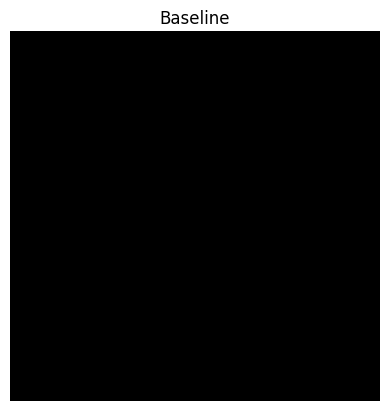

In [ ]:
# TODO: Modify this entire cell to account for pyplot.
plb.imshow(baseline)
plb.title("Baseline")
plb.axis("off")
plb.show()

In [ ]:
# TODO: Modify this entire cell to account for BERT.
def interpolate_images(baseline,image,alphas):
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    baseline_x = tf.expand_dims(baseline, axis=0)
    input_x = tf.expand_dims(image, axis=0)
    delta = input_x - baseline_x
    images = baseline_x + alphas_x * delta
    return images

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
def compute_gradients(images, target_class_idx):
    with tf.GradientTape() as tape:
        tape.watch(images)
        logits = model(images)
        probs = tf.nn.softmax(logits, axis-1)[:, target_class_idx]
    return tape.gradient(probs, images)

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
def integral_approximation(gradients):
    # riemann_trapezoidal
    grads = (gradients[:-1] + gradients[1:]) / tf.constant(2.0)
    integrated_gradients = tf.math.reduce_mean(grads, axis=0)
    return integrated_gradients

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
@tf.function
def one_batch(baseline, image, alpha_batch, target_class_idx):
    interpolated_path_input_batch = interpolate_images(baseline=baseline,
                                                       image=image,
                                                       alphas=alpha_batch)
    gradient_batch = compute_gradients(images=interpolated_path_input_batch, 
                                       target_class_idx=target_class_idx)
    return gradient_batch

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
def integrated_gradients(baseline,
                         image, 
                         target_class_idx, 
                         m_steps=50, 
                         batch_size=32):
    alphas = tf.linspace(start=0.0, stop=1.0,num=m_steps+1)
    gradient_batches = []

    for alpha in tf.range(0, len(alphas), batch_size):
        from_ = alpha
        to = tf.minimum(from_ + batch_size, len(alphas))
        alpha_batch = alphas[from_:to]

        gradient_batch = one_batch(baseline, image, alpha_batch, target_class_idx)
        gradient_batches.append(gradient_batch)

    total_gradients = tf.concat(gradient_batches, axis=0)

    avg_gradients = integral_approximation(gradients=total_gradients)

    integrated_gradients = (image - baseline) * avg_gradients

    return integrated_gradients

In [ ]:
# TODO: Modify this entire cell to account for pyplot
ig_attributions = integrated_gradients(baseline=baseline,
                                       image=image_name_tensors["Fireboat"],
                                       target_class_idx=555,
                                       m_steps=240)

In [ ]:
# TODO: Modify this entire cell to account for BERT and pytorch
print(ig_attributions.shape)